# This is the solution to the 2D Truck packing problem



In [1]:
# Installing dependencies
!pip install pulp matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 7.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Defining the solver

import pulp
import matplotlib.pyplot as plt

# Container dimensions
W1, L1 = 56.5, 135
W2, L2 = 135, 56.5

TRUCK_WIDTH = 250

def solve_packing(N):
    model = pulp.LpProblem("2D_Packing", pulp.LpMinimize)

    # Variables
    x = [pulp.LpVariable(f"x_{i}", lowBound=0) for i in range(N)]
    y = [pulp.LpVariable(f"y_{i}", lowBound=0) for i in range(N)]
    r = [pulp.LpVariable(f"r_{i}", cat="Binary") for i in range(N)]

    L = pulp.LpVariable("L", lowBound=0)

    # Width and height depending on rotation
    w = [r[i]*W2 + (1-r[i])*W1 for i in range(N)]
    h = [r[i]*L2 + (1-r[i])*L1 for i in range(N)]

    # Objective: minimize used length
    model += L

    # Constraints: inside strip
    for i in range(N):
        model += y[i] + w[i] <= TRUCK_WIDTH
        model += x[i] + h[i] <= L

    # Non-overlap constraints
    M = 2000  # Big-M

    for i in range(N):
        for j in range(i+1, N):
            b1 = pulp.LpVariable(f"b1_{i}_{j}", cat="Binary")
            b2 = pulp.LpVariable(f"b2_{i}_{j}", cat="Binary")
            b3 = pulp.LpVariable(f"b3_{i}_{j}", cat="Binary")
            b4 = pulp.LpVariable(f"b4_{i}_{j}", cat="Binary")

            model += x[i] + h[i] <= x[j] + M*(1-b1)
            model += x[j] + h[j] <= x[i] + M*(1-b2)
            model += y[i] + w[i] <= y[j] + M*(1-b3)
            model += y[j] + w[j] <= y[i] + M*(1-b4)

            model += b1 + b2 + b3 + b4 >= 1

    # Solve
    model.solve(pulp.PULP_CBC_CMD(msg=0))

    solution = []
    for i in range(N):
        solution.append({
            "x": x[i].value(),
            "y": y[i].value(),
            "rot": int(r[i].value())
        })

    return L.value(), solution

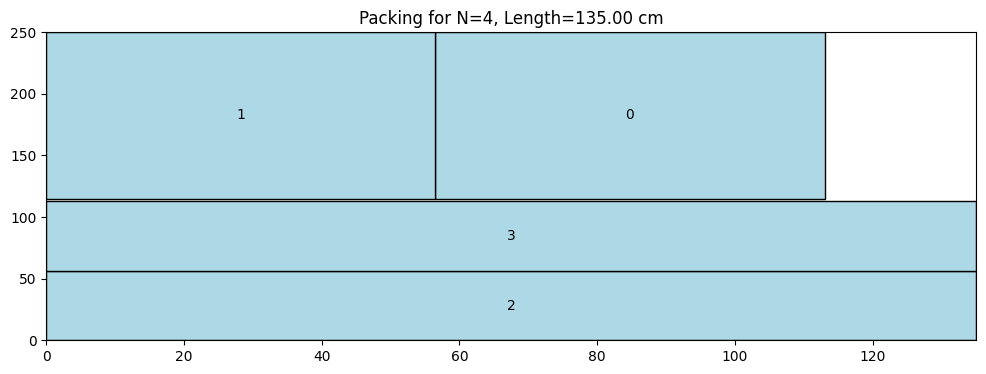

In [20]:
N = 4
L, solution = solve_packing(N)
plot_solution(N, L, solution)

## HERE IS CODE FOR USING CP-SAT


In [27]:
!pip install ortools matplotlib



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Solver CP-SAT
from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

def solve_packing_cpsat(N):
    model = cp_model.CpModel()

    # Dimensions (scaled to integers to avoid floats)
    SCALE = 10
    W1, L1 = int(56.5*SCALE), int(135*SCALE)
    W2, L2 = int(135*SCALE), int(56.5*SCALE)

    TRUCK_WIDTH = int(250*SCALE)

    # Variables
    x = [model.NewIntVar(0, 20000, f"x_{i}") for i in range(N)]
    y = [model.NewIntVar(0, TRUCK_WIDTH, f"y_{i}") for i in range(N)]

    r = [model.NewBoolVar(f"r_{i}") for i in range(N)]

    # Width/height depending on rotation
    w = []
    h = []

    for i in range(N):
        wi = model.NewIntVar(min(W1, W2), max(W1, W2), f"w_{i}")
        hi = model.NewIntVar(min(L1, L2), max(L1, L2), f"h_{i}")

        model.Add(wi == W1).OnlyEnforceIf(r[i].Not())
        model.Add(wi == W2).OnlyEnforceIf(r[i])

        model.Add(hi == L1).OnlyEnforceIf(r[i].Not())
        model.Add(hi == L2).OnlyEnforceIf(r[i])

        w.append(wi)
        h.append(hi)

    # Length variable
    L = model.NewIntVar(0, 20000, "L")

    # Boundary constraints
    for i in range(N):
        model.Add(y[i] + w[i] <= TRUCK_WIDTH)
        model.Add(x[i] + h[i] <= L)

    # No-overlap using intervals
    x_intervals = []
    y_intervals = []

    for i in range(N):
        x_end = model.NewIntVar(0, 20000, f"x_end_{i}")
        model.Add(x_end == x[i] + h[i])

        xi = model.NewIntervalVar(x[i], h[i], x_end, f"x_int_{i}")

        y_end = model.NewIntVar(0, TRUCK_WIDTH, f"y_end_{i}")
        model.Add(y_end == y[i] + w[i])

        yi = model.NewIntervalVar(y[i], w[i], y_end, f"y_int_{i}")

        x_intervals.append(xi)
        y_intervals.append(yi)

    model.AddNoOverlap2D(x_intervals, y_intervals)

    # Objective
    model.Minimize(L)

    # Solve
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    solver.parameters.num_search_workers = 8

    status = solver.Solve(model)

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None, None

    solution = []
    for i in range(N):
        solution.append({
            "x": solver.Value(x[i]) / SCALE,
            "y": solver.Value(y[i]) / SCALE,
            "w": solver.Value(w[i]) / SCALE,
            "h": solver.Value(h[i]) / SCALE,
        })

    return solver.Value(L) / SCALE, solution

In [5]:
# VISUALIZATION
def plot_solution(N, L, solution):
    fig, ax = plt.subplots(figsize=(12, 4))

    for i, box in enumerate(solution):
        rect = plt.Rectangle(
            (box["x"], box["y"]),
            box["h"], box["w"],
            edgecolor='black'
        )
        ax.add_patch(rect)

        ax.text(
            box["x"] + box["h"]/2,
            box["y"] + box["w"]/2,
            str(i),
            ha='center', va='center'
        )

    ax.set_xlim(0, L)
    ax.set_ylim(0, 250)
    ax.set_title(f"N={N}, Length={L:.2f} cm")
    plt.gca().invert_yaxis()
    plt.show()

Optimal Length: 1400.0


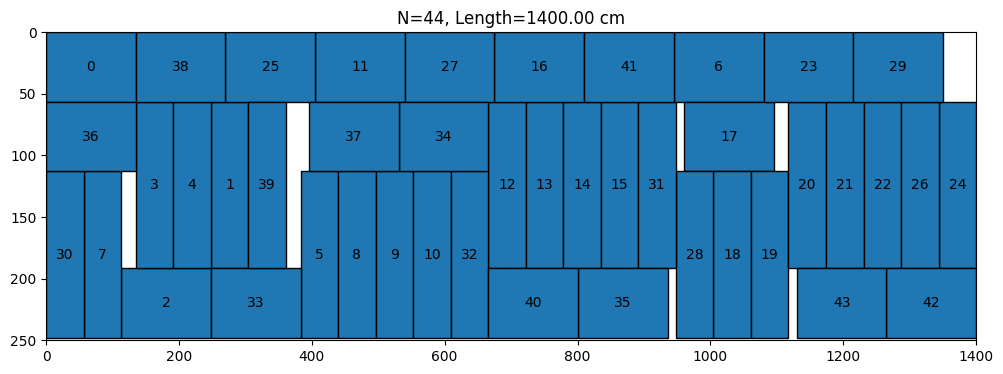

In [4]:
N = 44
L, solution = solve_packing_cpsat(N)

print("Optimal Length:", L)
plot_solution(N, L, solution)